In [1]:
import optics_design_workbench.jupyter_utils as opw
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [73]:
# restore default value for spherical lens radius
with opw.FreecadDocument() as doc:
  doc.Sphere.Radius = 10

# Opening and manipulating our .FCStd file

In [3]:
with opw.FreecadDocument() as doc:
  print(f'path: {doc.path()}')
  print(f'Sphere.Radius: {doc.Sphere.Radius}')
  print(f'result of .get method: {doc.Sphere.Radius.get()}')

path: ./GettingStarted.FCStd
Sphere.Radius: <FreecadProperty Sphere.Radius, value: 10.0 mm>
result of .get method: 10.0 mm


In [4]:
with opw.FreecadDocument() as doc:
  doc.Sphere.Radius = 10.1

In [28]:
opw.openFreecadGui()

[Optics Design 14:31:09.954823] FreeCAD finished (exit code 0)


<RawFolder simulation-run-000066/ UID=59eb4d28-55f6-4821-a2a7-6bb60bdf00df>
[Optics Design 17:03:00.460625] finding all result files in ./GettingStarted.OpticsDesign/raw/simulation-run-000066/**/*-hits.pkl


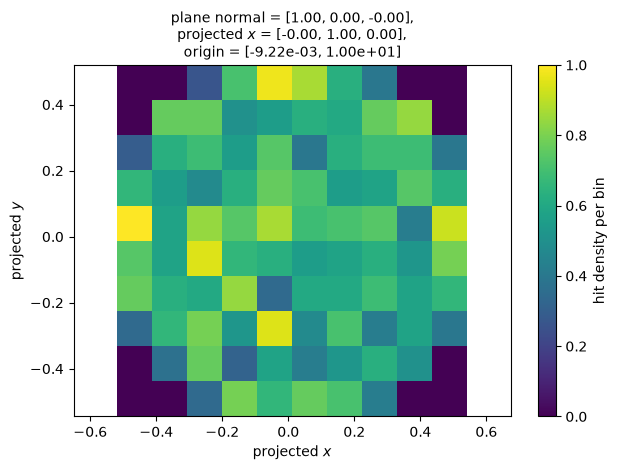

In [74]:
with opw.FreecadDocument() as doc:
  doc.OpticalSimulationSettings.EndAfterRays = 1e3
  raw = doc.runSimulation('true')
print(raw)
raw.loadHits().histogram().plot()

# Run simple parameter sweep

In [2]:
def calcFwhm(hits):
  'calculate spot FWHM from a given point cloud'
  
  # setup list of fwhm results for different azimuth angles
  fwhmList = []

  # calculate polar histogram
  polarHist = hits.histogram(
        binCoords='polar', 
        bins=[np.arange(0, 2*np.pi, np.pi/2), 
              np.geomspace(1e-3, 5, 500)])

  # loop through azimuth angles if histogram
  phis, r, hists = polarHist.byAzimuth()
  for phi, dens in zip(phis, hists):
    
    # skip if no ray hit the bins we setup
    if max(dens) > 0:
      
      # perform and plot line fit of loglog data
      a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
      rFit = np.geomspace(min(r), max(r[dens>10][:10]), 100)
      fitDens = np.exp( a*np.log(rFit)+b )
      
      # calculate, plot and store fwhm from fit in list
      try:
        fwhm = min(rFit[fitDens<=max(dens)/2])
        fwhmList.append(fwhm)
      # silently ignore errors in cases where fwhm is ill defined
      except ValueError:
        pass
  
  # return mean fwhm result
  return np.mean(fwhmList) if len(fwhmList) else np.nan

In [4]:
# prepare parameter and results list
radii = np.linspace(9, 11, 30)
fwhms = []

# open the .FCStd file
with opw.FreecadDocument() as doc:

  # setup progress tracking
  opw.setupProgressTracker(totalSimulations=len(radii))

  # establish settings we want to use for each simulation
  doc.OpticalSimulationSettings.EndAfterRays = 1e3

  # iterate over a range of lens radii
  for radius in radii:

    # update spherical lens radius
    doc.Sphere.Radius = radius

    # run a true-random simulation
    rawFolder = doc.runSimulation('true')
    
    # load ray hit point cloud
    hits = rawFolder.loadHits()
  
    # calculate the spot FWHM and append to result list
    fwhms.append( calcFwhm(hits) ) 

simulations done 30/30
simulations ended after 12m 43s


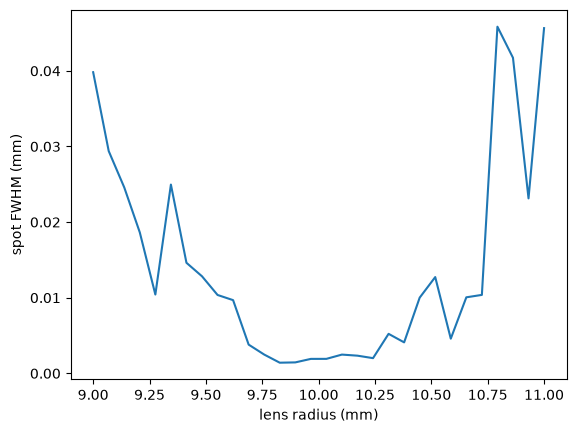

In [5]:
# plot fwhm vs. lens radius
plt.plot(radii, fwhms)
plt.xlabel('lens radius (mm)')
plt.ylabel('spot FWHM (mm)');

In [ ]:
# set lens radius in the .FCStd file to the radius 
# corresponding to the smallest spot 
with opw.FreecadDocument() as doc:
  doc.Sphere.Radius = radii[np.argmin(fwhms)]